In [25]:


from dotenv import load_dotenv
load_dotenv()


True

In [26]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from typing import Literal

In [27]:
##Coding,google_search,weather

class FlowState(BaseModel):
    question:str=Field(description="What User Asked")
    category:Literal["coding","google_search","weather"]=Field(default="google_search")
    answer:str=Field(default="")

In [28]:
#for structured Output
class QuestionCategory(BaseModel):
    category:Literal["coding","google_search","weather"]=Field(default="google_search",description="Question Category")


In [29]:
llm=ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [30]:
def check_question_category(state:FlowState)->FlowState:
    st_llm=llm.with_structured_output(QuestionCategory)
    res=st_llm.invoke(f"I want to know the category of my question,Question is {state.question} If your not sure just give 'google_search'as a category")
    state.category=res.category
    return state

In [31]:
flow=FlowState(question="What is the temperature in a india")
check_question_category(flow)

FlowState(question='What is the temperature in a india', category='weather', answer='')

In [32]:
def route(state:FlowState)->Literal["coding","google_search","weather"]:
    return state.category

In [33]:
def code_node(state:FlowState)->FlowState:
    res=llm.invoke(f"Your a coding expert:{state.question}")
    state.answer=res
    return state


def weather_node(state:FlowState)->FlowState:
    res=weather_agent.invoke({"messages":[
        {"role":"user","content":state.question}
    ]})
    state.answer=res["messages"][-1].content
    return state



def google_search_node(state:FlowState)->FlowState:
    res=google_agent.invoke({"messages":[
        {"role":"user","content":state.question}
    ]})
    state.answer=res["messages"][-1].content
    return state


In [34]:
graph=StateGraph(FlowState)


graph.add_node("check question category",check_question_category)

#node name and category needs to be same so that route can identify

graph.add_node("coding",code_node)
graph.add_node("google_search",google_search_node)
graph.add_node("weather",weather_node)


graph.add_edge(START,"check question category")
graph.add_conditional_edges("check question category",route)
graph.add_edge("coding",END)
graph.add_edge("google_search",END)
graph.add_edge("weather",END)

graph=graph.compile()

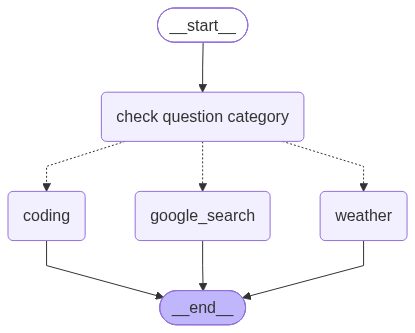

In [35]:
graph

In [36]:
res=graph.invoke({"question":"how to find the sum using python"})

In [37]:
print(res["answer"].content[0]["text"])

As a coding expert, I can tell you that finding the sum in Python is very straightforward. Depending on what you are trying to add up (a list of numbers, a range, or individual variables), there are a few different ways to do it.

Here are the most common and efficient ways:

---

### 1. Using the built-in `sum()` function (Most Common)
If you have a list, tuple, or set of numbers, the built-in `sum()` function is the Pythonic way to do it.

```python
# A list of numbers
numbers = [10, 20, 30, 40, 50]

# Find the sum
total = sum(numbers)

print(total)  # Output: 150
```

#### Adding numbers with a starting value (`start`)
The `sum()` function also takes an optional second argument, which is a value to add to the total (defaults to `0`).

```python
numbers = [10, 20, 30]
total = sum(numbers, 100)  # Starts at 100 and adds the list items

print(total)  # Output: 160
```

---

### 2. Summing a range of numbers
If you want to find the sum of a sequence of numbers (e.g., numbers from 1 to 1

In [38]:
from langchain.agents import create_agent
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.tools import tool

In [39]:
search=GoogleSerperAPIWrapper()
tools=[search.run]

google_agent=create_agent(
    model=llm,
    tools=tools,
    system_prompt="Your an agent and search for any question on google",
)

##weather agent
@tool
def get_weather(city:str):
    """
        It provides real time weather details for any city
    """
    return f"the current temp in {city} is 23C"

weather_agent=create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="Your an agent and can provide real time weather details",
)

In [40]:
res=graph.invoke({"question":"What is the weather of kerala"})


In [42]:
print(res["answer"][0]["text"])



The current temperature in Kerala is 23°C.
